In [1]:
%pip install tensorflow opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 763.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 135.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 94.4 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
import os
import cv2
from matplotlib import pyplot as plt

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:
train_data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/brain_mri_dataset/Training')

Found 5000 files belonging to 4 classes.


In [47]:
data_iterator = train_data.as_numpy_iterator()

In [48]:
batch = data_iterator.next()

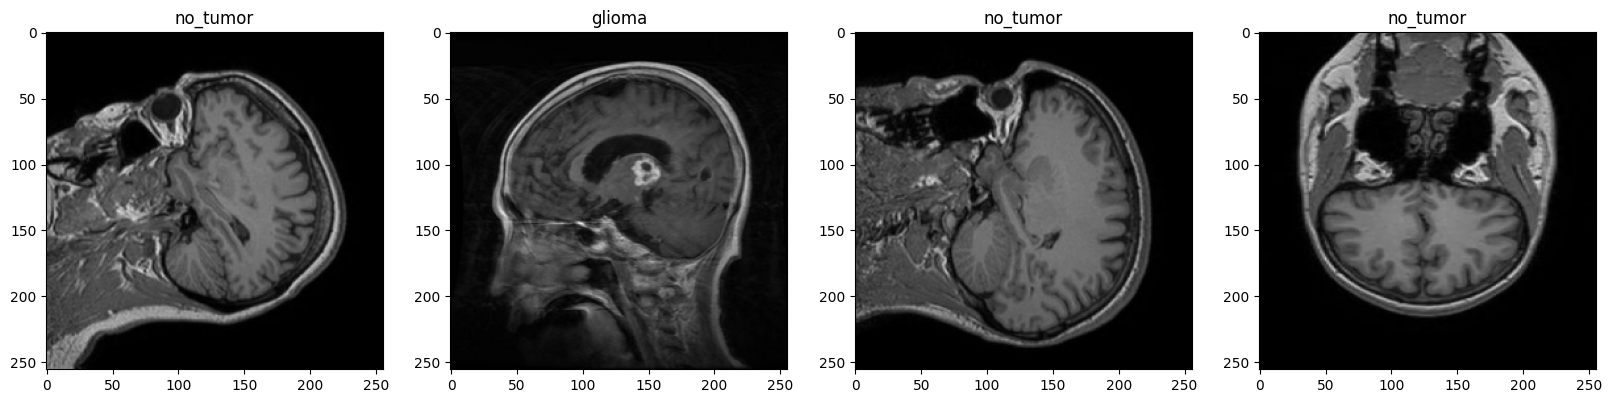

In [49]:
class_names = train_data.class_names
fig, ax = plt.subplots(ncols = 4, figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(class_names[batch[1][idx]])

In [50]:
train_data = train_data.map(lambda x,y: (x/255, y))

In [51]:
scaled = train_data.as_numpy_iterator().next()

In [52]:
scaled[0].max()

np.float32(1.0)

In [53]:
tf.random.set_seed(42)

train_data = train_data.shuffle(buffer_size=len(train_data), seed=42, reshuffle_each_iteration=False)

train_size = int(len(train_data) * 0.8)
val_size = len(train_data) - train_size
train = train_data.take(train_size)
val = train_data.skip(train_size)

In [55]:
test_data = tf.keras.utils.image_dataset_from_directory('/content/drive/MyDrive/brain_mri_dataset/Testing')
test_data = test_data.map(lambda x, y: (x/255, y))

Found 1000 files belonging to 4 classes.


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [57]:
model = Sequential()

model.add(Conv2D(16, (3,3), 1, activation ='relu', input_shape = (256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation ='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation ='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile('adam', loss = tf.losses.SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    14,745,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,770,468 (56.34 MB)

 Trainable params: 14,770,468 (56.34 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)

In [61]:
hist = model.fit(train, epochs = 20, validation_data = val, callbacks=[early_stop, checkpoint])

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 290ms/step - accuracy: 0.6346 - loss: 0.9301 - val_accuracy: 0.7529 - val_loss: 0.6153
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 194ms/step - accuracy: 0.8149 - loss: 0.4908 - val_accuracy: 0.8486 - val_loss: 0.3716
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 194ms/step - accuracy: 0.8504 - loss: 0.3861 - val_accuracy: 0.9219 - val_loss: 0.2215
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 199ms/step - accuracy: 0.9037 - loss: 0.2637 - val_accuracy: 0.9424 - val_loss: 0.1915
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 46s 232ms/step - accuracy: 0.9238 - loss: 0.2046 - val_accuracy: 0.9424 - val_loss: 0.1669
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 204ms/step - accuracy: 0.9341 - loss: 0.1754 - val_accuracy: 0.9619 - val_loss: 0.1194
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 206ms/step - accuracy: 0.9575 - loss: 0.1223 - val_accuracy: 0.9805 - val_loss: 0.0614
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 184ms/step - accuracy: 0.9615 - loss: 0

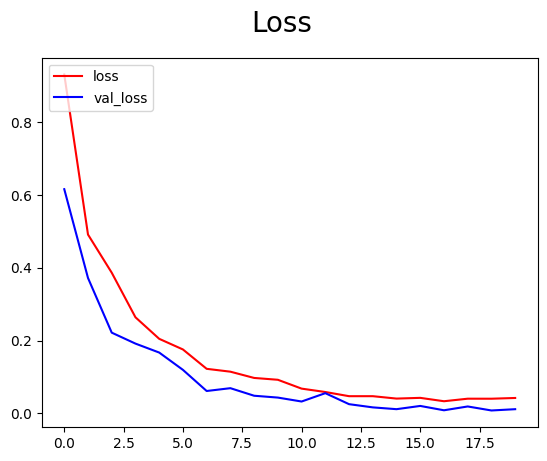

In [62]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'red', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'blue', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()


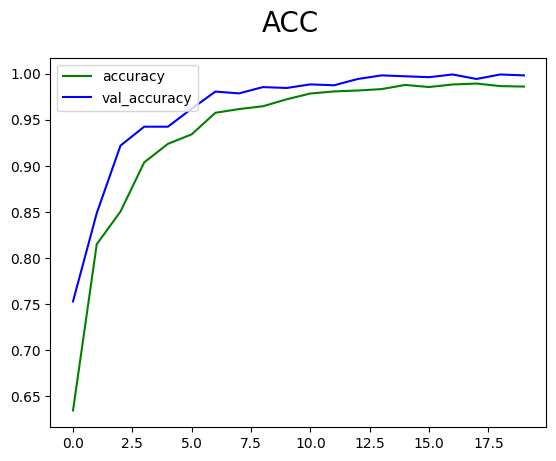

In [63]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'green', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'blue', label = 'val_accuracy')
fig.suptitle('ACC', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

In [64]:
model.evaluate(test_data)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.9560 - loss: 0.1727


[0.17272354662418365, 0.9559999704360962]

In [65]:
%pip install scikit-learn seaborn

              precision    recall  f1-score   support

      glioma       0.96      0.93      0.94       254
  meningioma       0.92      0.93      0.93       306
    no_tumor       0.97      0.99      0.98       140
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



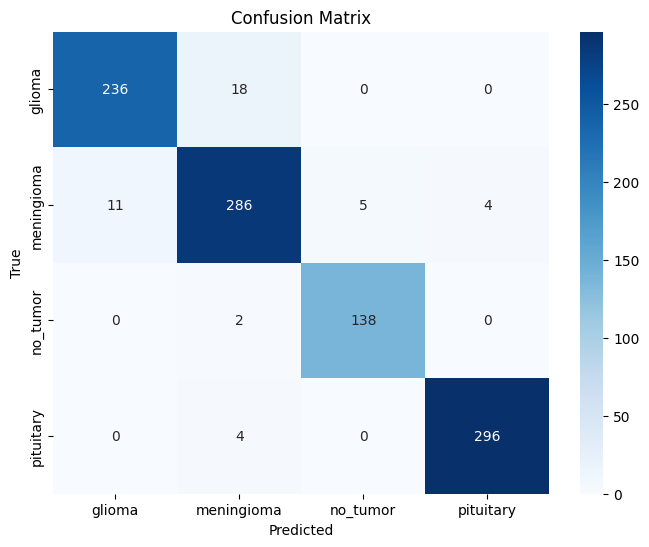

In [66]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = []
y_pred = []
for x, y in test_data:
    preds = model.predict(x, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
model.save('CNNTest_v1.0.keras')